<a href="https://colab.research.google.com/github/94Akriti/DL-ML-USING-PYTORCH/blob/main/Custom_Datasets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Get Data

Subset of Food101 dataset

We will work on dataset with 3 classes of food only and then gradually increase the data to 750 training 250 testing dataset

In [4]:
import requests
import zipfile
from pathlib import Path

data_path  = Path("data/")
image_path = data_path / "pizza_steak_sushi"

if image_path.is_dir():
    print(f"{image_path} directory exists------skipping download")
else:
    print(f" {image_path} does not exist, creating one...")
    image_path.mkdir(parents=True, exist_ok = True)


with open(data_path / "pizza_steak_sushi.zip","wb") as f:
  request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
  print("Downloading pizza, steak, sushi data...")
  f.write(request.content)
with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip","r") as zip_ref:
  print("Unzipping pizza, steak, and sushi data...")
  zip_ref.extractall(image_path)

data/pizza_steak_sushi directory exists------skipping download
Unzipping pizza, steak, and sushi data...


## Data Preparation and exploration

In [6]:
import os
def walk_through_dir(dir_path):
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in {dirpath}")
walk_through_dir(image_path)


There are 2 directories and 0 images in data/pizza_steak_sushi
There are 3 directories and 0 images in data/pizza_steak_sushi/train
There are 0 directories and 75 images in data/pizza_steak_sushi/train/steak
There are 0 directories and 72 images in data/pizza_steak_sushi/train/sushi
There are 0 directories and 78 images in data/pizza_steak_sushi/train/pizza
There are 3 directories and 0 images in data/pizza_steak_sushi/test
There are 0 directories and 19 images in data/pizza_steak_sushi/test/steak
There are 0 directories and 31 images in data/pizza_steak_sushi/test/sushi
There are 0 directories and 25 images in data/pizza_steak_sushi/test/pizza


In [7]:
train_dir = image_path / "train"
test_dir = image_path / "test"
train_dir,test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

## Visualize the images

* Get all the image paths
* Pick random image path using Python's random.choice()
* Get image class name using pathlib.Path.parent.stem
* Using Python's PIL the images can be opened
* show images and print metadata

### Using PIL

Random Image Path: data/pizza_steak_sushi/train/sushi/794647.jpg
 Image Class:sushi
Image size: 512
 Image width: 512


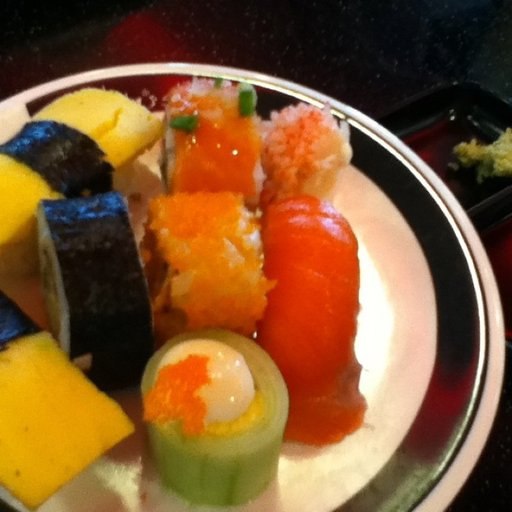

In [15]:
import random
from PIL import Image

# random.seed(42)

image_path_list = list(image_path.glob("*/*/*.jpg"))
random_image_path = random.choice(image_path_list)
print(f"Random Image Path: {random_image_path}")

image_class = random_image_path.parent.stem
print(f" Image Class:{image_class}")

img = Image.open(random_image_path)
print(f"Image size: {img.height}")
print(f" Image width: {img.width}")
img

### Using Matplotlib

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

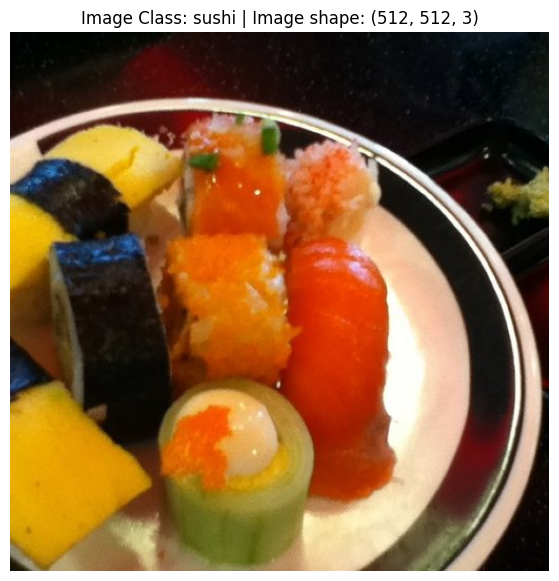

In [20]:
import numpy as np
import matplotlib.pyplot as plt

image_as_array = np.asarray(img)

plt.figure(figsize=(10,7))
plt.imshow(image_as_array)
plt.title(f"Image Class: {image_class} | Image shape: {image_as_array.shape}")
plt.axis(False)

array([[[ 1,  3,  2],
        [ 2,  4,  3],
        [ 2,  4,  3],
        ...,
        [17, 21, 22],
        [18, 22, 23],
        [19, 23, 24]],

       [[ 1,  3,  2],
        [ 2,  4,  3],
        [ 2,  4,  3],
        ...,
        [13, 17, 18],
        [14, 18, 19],
        [15, 19, 20]],

       [[ 1,  3,  2],
        [ 2,  4,  3],
        [ 2,  4,  3],
        ...,
        [12, 16, 17],
        [13, 17, 18],
        [14, 18, 19]],

       ...,

       [[18, 19, 11],
        [17, 18, 10],
        [18, 18, 10],
        ...,
        [ 4,  3,  1],
        [ 5,  4,  2],
        [ 5,  4,  2]],

       [[18, 20, 17],
        [18, 19, 14],
        [20, 19, 15],
        ...,
        [ 3,  2,  0],
        [ 4,  3,  1],
        [ 4,  3,  1]],

       [[15, 17, 16],
        [15, 17, 16],
        [18, 17, 15],
        ...,
        [ 3,  2,  0],
        [ 3,  2,  0],
        [ 4,  3,  1]]], dtype=uint8)
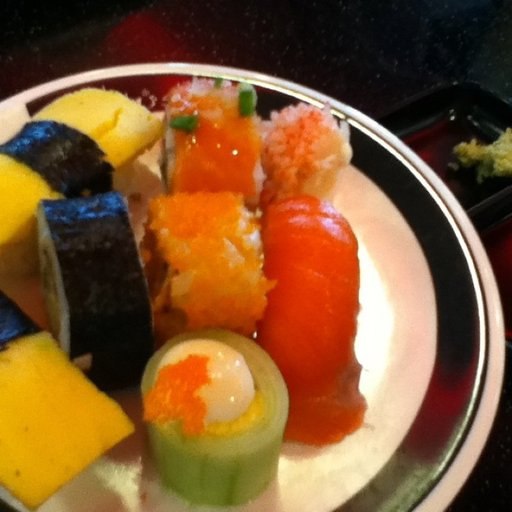

In [18]:
image_as_array

## Transforming data

To utilize image data in Pytorch models we require to follow below standard steps:

1. turn target data into tensors
2. Transform the tensors into torch.utils.data.Dataset and then torch.utils.data.DataLoader using Dataset and DataLoader.

In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
